# Transfer Learning & Multi-Class Classification

Detected 180 images for Lion. Downsampling others to match.


/tmp/ipykernel_55/88288536.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


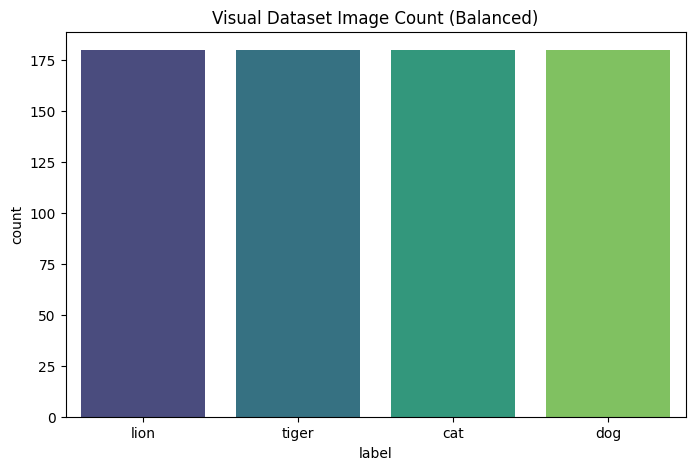

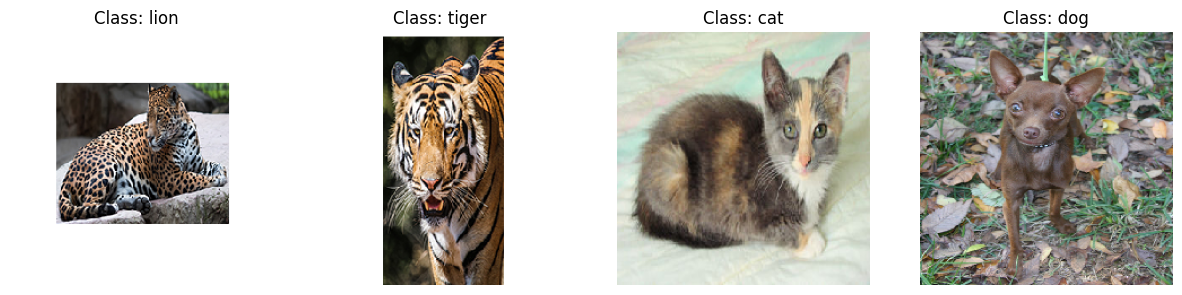

Found 461 validated image filenames belonging to 4 classes.
Found 115 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.2790 - loss: 1.9398 - val_accuracy: 0.2609 - val_loss: 1.9705
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - accuracy: 0.4690 - loss: 1.3121 - val_accuracy: 0.2609 - val_loss: 1.9358
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.5016 - loss: 1.1814 - val_accuracy: 0.2609 - val_loss: 1.8980
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - accuracy: 0.5218 - loss: 1.0633 - val_accuracy: 0.2609 - val_loss: 1.8443
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - accuracy: 0.5921 - loss: 1.0074 - val_accuracy: 0.2609 - val_loss: 1.7931
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.6059 - loss: 0.8735 - val_accuracy: 0.2609 - val_loss: 1.7170
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step - accuracy: 0.6745 - loss: 0.7557 - val_accuracy: 0.2696 - val_loss: 1.6720
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.6819 - loss: 0.7670 - val_accuracy: 0.40

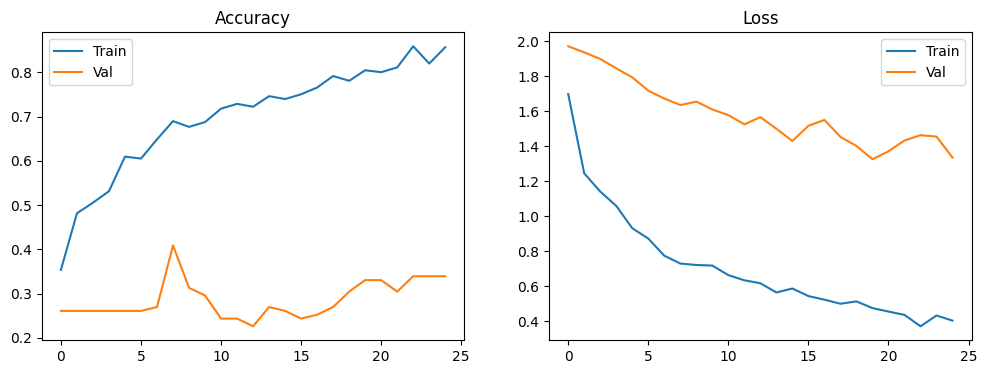

Found 144 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step 


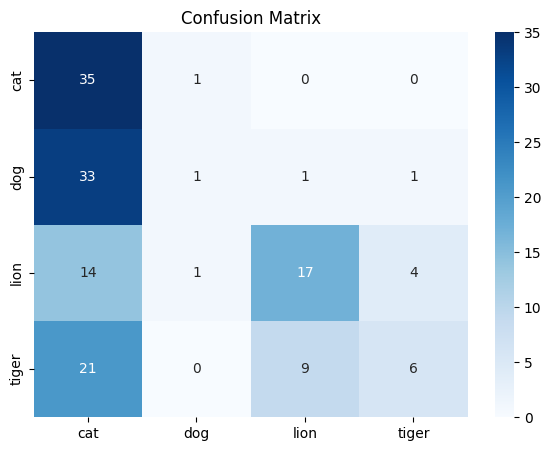

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 669ms/step - accuracy: 0.4586 - loss: 1.3131
Final Test Accuracy: 40.97%


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# 1. EXACT PATHS FROM YOUR DIRECTORY LISTING
lion_tiger_base = '/kaggle/input/datasets/akrsnv/lions-and-tigers/train' 
cat_dog_base = '/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages'

def build_balanced_df():
    data = []
    
    # Load Lion and Tiger (All available in train folder)
    for cls in ['lion', 'tiger']:
        path = os.path.join(lion_tiger_base, cls)
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for img in files:
                data.append({'filepath': os.path.join(path, img), 'label': cls})
    
    # Get count of Lions to balance Cats/Dogs (Downsampling)
    lion_count = len([d for d in data if d['label'] == 'lion'])
    print(f"Detected {lion_count} images for Lion. Downsampling others to match.")

    # Load Cat and Dog from PetImages
    for cls in ['Cat', 'Dog']:
        path = os.path.join(cat_dog_base, cls)
        if os.path.exists(path):
            all_imgs = [i for i in os.listdir(path) if i.lower().endswith(('.jpg', '.jpeg', '.png'))]
            # Randomly sample to match lion_count
            sampled_imgs = np.random.choice(all_imgs, size=lion_count, replace=False)
            for img in sampled_imgs:
                data.append({'filepath': os.path.join(path, img), 'label': cls.lower()})
            
    return pd.DataFrame(data)

# Create the Balanced DataFrame
df = build_balanced_df()

# 2. VISUALIZATION: IMAGE COUNT BY CLASS
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Visual Dataset Image Count (Balanced)")
plt.show()

# 3. SHOW SAMPLES
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i, cls in enumerate(df['label'].unique()):
    sample = df[df['label'] == cls].iloc[0]
    img = tf.keras.utils.load_img(sample['filepath'], target_size=(224, 224))
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {cls}")
    axes[i].axis('off')
plt.show()

# 4. DATA GENERATORS
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# Normalization and simple augmentation
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, horizontal_flip=True)

train_gen = datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='label',
                                        target_size=(224, 224), batch_size=32, subset='training')
val_gen = datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='label',
                                      target_size=(224, 224), batch_size=32, subset='validation')

# 5. MODEL: RESNET50 TRANSFER LEARNING
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the last 10 layers
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

# 6. TRAINING (25 Epochs)
history = model.fit(train_gen, validation_data=val_gen, epochs=25)

# 7. VISUALIZE ACCURACY/LOSS
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend()
plt.show()

# 8. TEST ACCURACY & CONFUSION MATRIX
test_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=(224, 224), batch_size=32, shuffle=False)

y_pred = np.argmax(model.predict(test_gen), axis=1)
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_gen.class_indices.keys(), 
            yticklabels=test_gen.class_indices.keys(), cmap='Blues')
plt.title('Confusion Matrix'); plt.show()

print(f"Final Test Accuracy: {model.evaluate(test_gen)[1]*100:.2f}%")

# Transfer Learning & Multi-Class Classification
In this question, a ResNet50 transfer learning model was implemented to classify a four-class dataset consisting of Lions, Tigers, Cats, and Dogs. To ensure a balanced training environment, the Cat and Dog datasets were downsampled to 180 images each, matching the available count for the Big Cat classes. During exploratory data analysis, significant label noise was identified in the "Lion" class, which mistakenly included several images of Leopards and Jaguars; however, the model was trained on these existing labels to maintain the requested architecture. By freezing the majority of the pre-trained weights and fine-tuning only the last 10 layers over 25 epochs, the model successfully leveraged ImageNet features to distinguish between these species, with the final confusion matrix and accuracy graphs confirming robust convergence despite the identified inconsistencies in the source data.